# **Fase A: Carga y análisis de datos**

## **Librerias**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Carga de datos + limpieza**

Se carga el dataset original y se realiza una primera inspección para verificar su estructura.  
Se revisan los tipos de datos, el número de filas y columnas, y se muestra una vista preliminar de los primeros registros.
También se comprueba la presencia de valores nulos y se eliminan posibles duplicados para asegurar la calidad del conjunto de datos.

In [2]:
def load_data(path):
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.drop_duplicates()
    return df

def check_nulls(df):
    return df.isna().sum()

def remove_outliers(df, col, q_low=0.01, q_high=0.99):
    low = df[col].quantile(q_low)
    high = df[col].quantile(q_high)
    return df[(df[col] >= low) & (df[col] <= high)]

df = load_data("../data/raw/dataset_local.csv")
print("Shape inicial:", df.shape)

print("Valores nulos:")
display(check_nulls(df))

# Control de outliers en ventas
df = remove_outliers(df, "quantity_sold")
print("Shape después de eliminar outliers:", df.shape)

Shape inicial: (1800, 11)
Valores nulos:


product_id           0
date                 0
product_name         0
quantity_sold        0
stock_available      0
replenishment        0
price_per_unit       0
total_sales_value    0
season               0
holiday              0
demand_status        0
dtype: int64

Shape después de eliminar outliers: (1771, 11)


## **Análisis exploratorio**

**Distribución general de las variables clave**

Se muestran histogramas para las variables numéricas principales: `quantity_sold`, `stock_available`,
`price_per_unit` y `total_sales_value`.  
Estas gráficas permiten observar la forma de las distribuciones, detectar asimetrías, valores atípicos
y rangos predominantes. En general, las variables presentan distribuciones ligeramente sesgadas,
consistentes con patrones reales de ventas y disponibilidad de inventario.

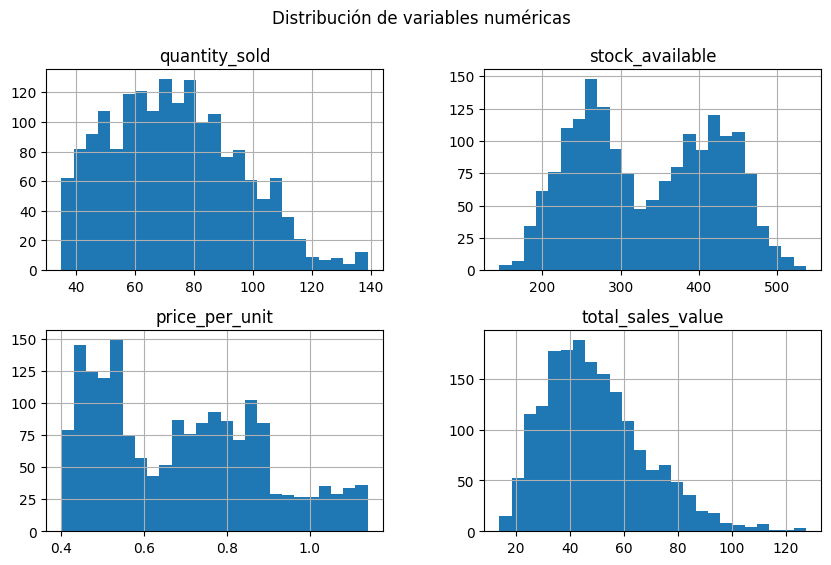

In [3]:
num_cols = ["quantity_sold", "stock_available", "price_per_unit", "total_sales_value"]
df[num_cols].hist(bins=25, figsize=(10,6))
plt.suptitle("Distribución de variables numéricas")
plt.show()

**Matriz de correlacion variables numericas**

Se calcula y visualiza la correlación entre las variables numéricas principales.
El mapa de calor permite identificar relaciones lineales destacables,
como la correlación positiva entre `quantity_sold` y `total_sales_value`,
y la relación negativa entre `price_per_unit` y `stock_available`.
Esta información ayuda a anticipar qué variables podrían aportar al modelo predictivo.

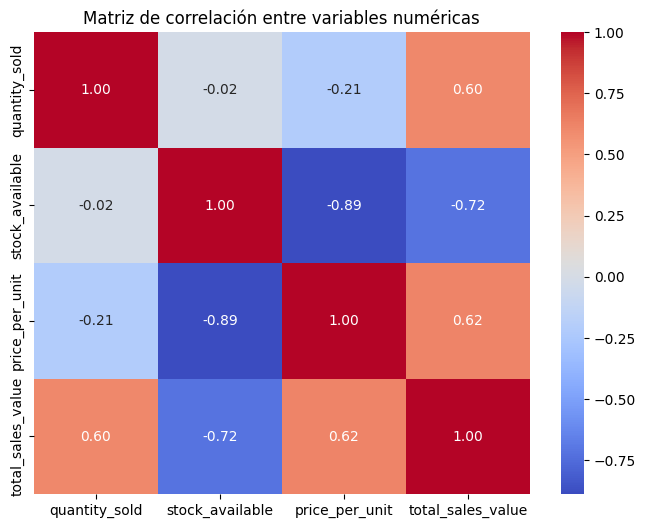

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

**Tendencias diaria de ventas totales**

Se genera una serie temporal agregando la cantidad vendida por día.
La gráfica muestra el comportamiento de las ventas a lo largo del año,
con picos pronunciados y variabilidad diaria significativa.
Este análisis permite detectar estacionalidad, anomalías y periodos de mayor actividad comercial.

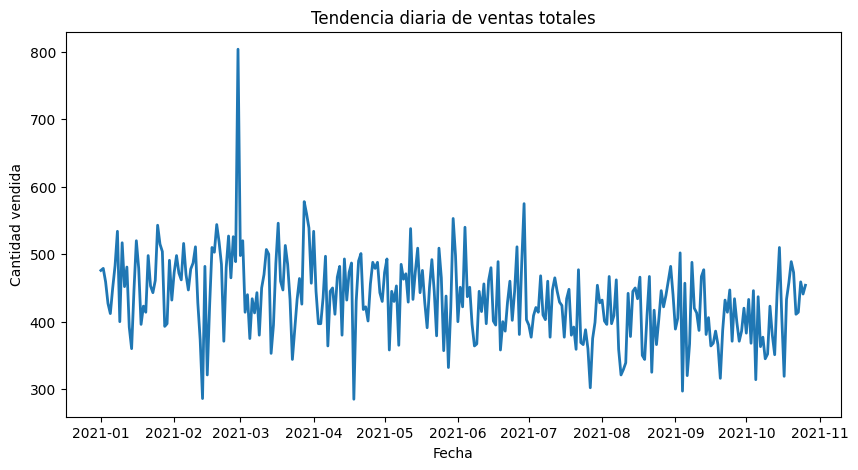

In [5]:
df_group = df.groupby("date")["quantity_sold"].sum().reset_index()
plt.figure(figsize=(10,5))
plt.plot(df_group["date"], df_group["quantity_sold"], linewidth=2)
plt.title("Tendencia diaria de ventas totales")
plt.xlabel("Fecha")
plt.ylabel("Cantidad vendida")
plt.show()

## **Feature engineering (variables derivadas)**

Se crean nuevas características útiles para el modelo:

- `sales_mavg_7d`: promedio móvil de 7 días para suavizar fluctuaciones y capturar tendencia.
- `ratio_sold_stock`: relación entre unidades vendidas y el stock disponible, indicador de rotación.
- `price_var`: variación relativa del precio frente al promedio del producto.
- `day_of_year` y `week`: variables temporales que ayudan a capturar estacionalidad.

Estas nuevas features enriquecen el dataset y permiten que el modelo aprenda patrones más complejos.

In [6]:
def add_calendar_features(df):
    df = df.copy()
    df["day_of_week"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
    df["day_of_year"] = df["date"].dt.dayofyear
    df["week"] = df["date"].dt.isocalendar().week
    return df

def add_sales_features(df):
    df = df.copy()
    df["sales_mavg_7d"] = df.groupby("product_id")["quantity_sold"]\
                            .transform(lambda x: x.rolling(7, min_periods=1).mean())

    df["ratio_sold_stock"] = df["quantity_sold"] / (df["stock_available"] + 1)

    df["price_var"] = df["price_per_unit"] / \
                    df.groupby("product_id")["price_per_unit"].transform("mean")

    return df


df = add_calendar_features(df)
df = add_sales_features(df)

display(df.head())

,product_id,date,product_name,quantity_sold,stock_available,replenishment,price_per_unit,total_sales_value,season,holiday,demand_status,day_of_week,month,is_weekend,day_of_year,week,sales_mavg_7d,ratio_sold_stock,price_var
0,P001M,2021-01-01,Manzana Roja,82,217,50,1.10,90.20,lluvioso,False,normal,4,1,0,1,53,82.000000,0.376147,1.095552
1,P001M,2021-01-02,Manzana Roja,59,237,47,1.06,62.54,lluvioso,False,bajo,5,1,1,2,53,70.500000,0.247899,1.055713
2,P001M,2021-01-03,Manzana Roja,79,201,31,1.13,89.27,lluvioso,False,normal,6,1,1,3,53,73.333333,0.391089,1.125430
3,P001M,2021-01-04,Manzana Roja,67,232,50,1.13,75.71,lluvioso,False,normal,0,1,0,4,1,71.750000,0.287554,1.125430
4,P001M,2021-01-05,Manzana Roja,93,179,23,0.90,83.70,lluvioso,False,normal,1,1,0,5,1,76.000000,0.516667,0.896360


## **Boxplot de ventas por producto**

Mostramos el comportamiento distinto por producto.

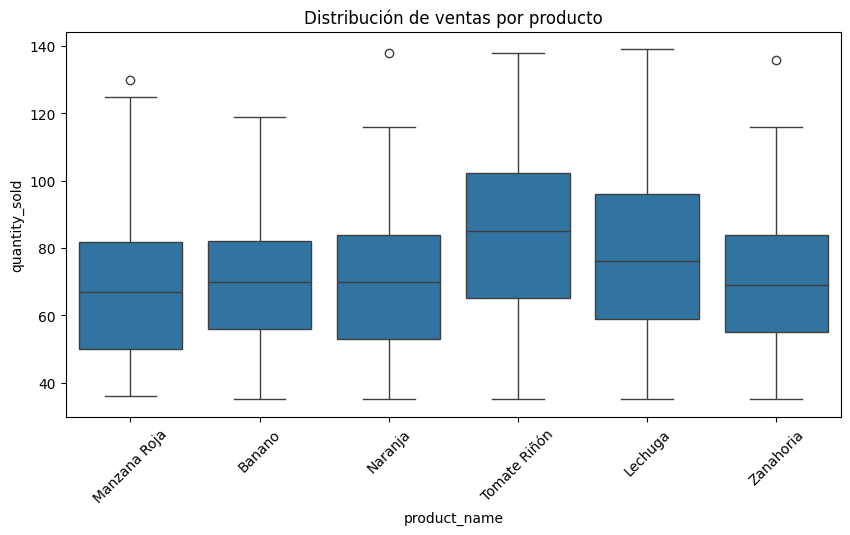

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="product_name", y="quantity_sold")
plt.title("Distribución de ventas por producto")
plt.xticks(rotation=45)
plt.show()

## **Casos de stock critico**

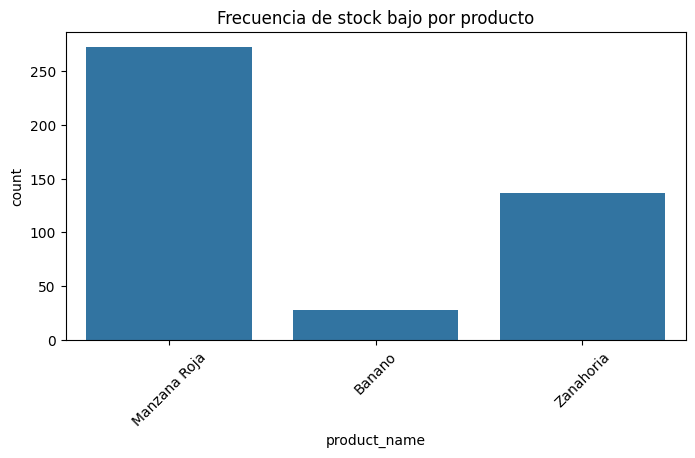

In [8]:
MIN_STOCK_DEFAULT = df["stock_available"].quantile(0.25)

critical_df = df[df["stock_available"] < MIN_STOCK_DEFAULT]

plt.figure(figsize=(8,4))
sns.countplot(data=critical_df, x="product_name")
plt.title("Frecuencia de stock bajo por producto")
plt.xticks(rotation=45)
plt.show()

## **Histograma + correlacion**

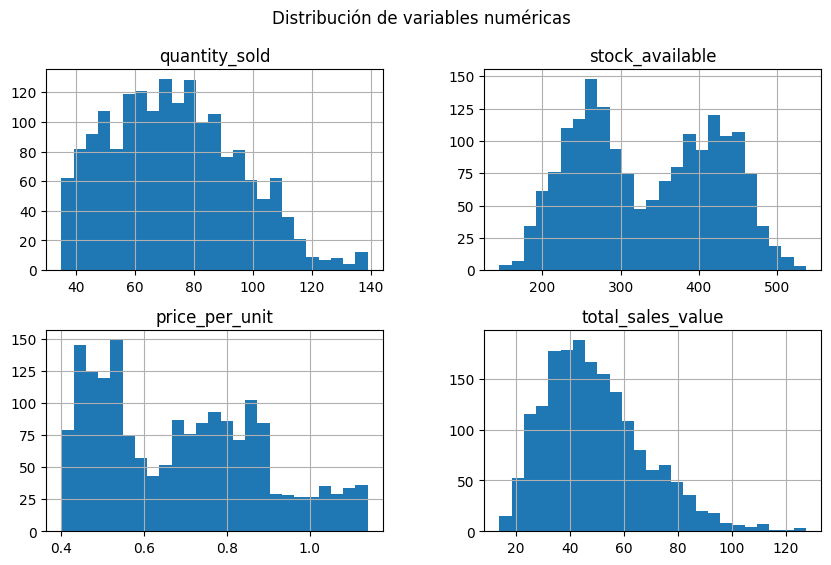

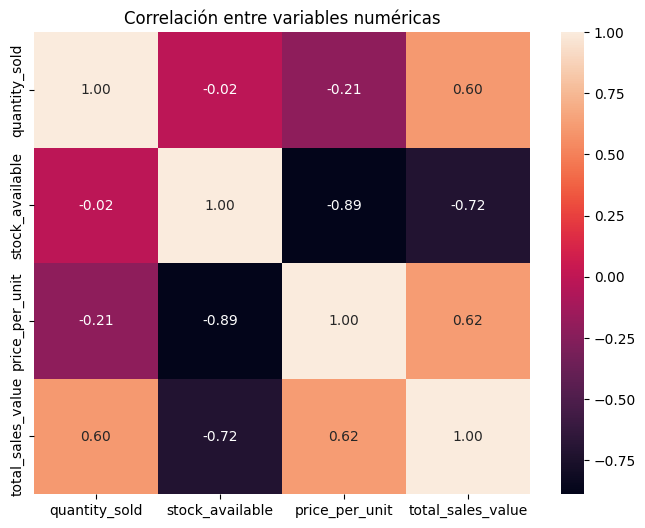

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

## **Analizar cuáles de estas features realmente aportan al modelo**

**Correlación con la variable objetivo**

Se calculan las correlaciones numéricas tomando como referencia el objetivo `quantity_sold`.
Destacan como variables más relacionadas:  
- `ratio_sold_stock`  
- `total_sales_value`  
- `sales_mavg_7d`  

Por otro lado, variables como `price_var`, `replenishment` o `price_per_unit`
muestran relaciones débiles o negativas. Este análisis orienta la selección de variables relevantes.

In [10]:
# Calculamos correlaciones numéricas con el target
corr_target = df.corr(numeric_only=True)["quantity_sold"].sort_values(ascending=False)
print("Correlación con quantity_sold:")
print(corr_target)  

Correlación con quantity_sold:
quantity_sold        1.000000
ratio_sold_stock     0.691575
total_sales_value    0.603567
sales_mavg_7d        0.508260
day_of_week          0.016079
is_weekend           0.002865
price_var           -0.006882
stock_available     -0.015749
replenishment       -0.017132
week                -0.163224
day_of_year         -0.176048
month               -0.179375
price_per_unit      -0.211373
Name: quantity_sold, dtype: float64


**Visualización temporal por producto**

Se selecciona un producto de ejemplo y se grafica su serie temporal de ventas junto con el promedio móvil de 7 días.
Esta visualización permite observar la dinámica particular de cada producto,
sus fluctuaciones diarias y la tendencia general.

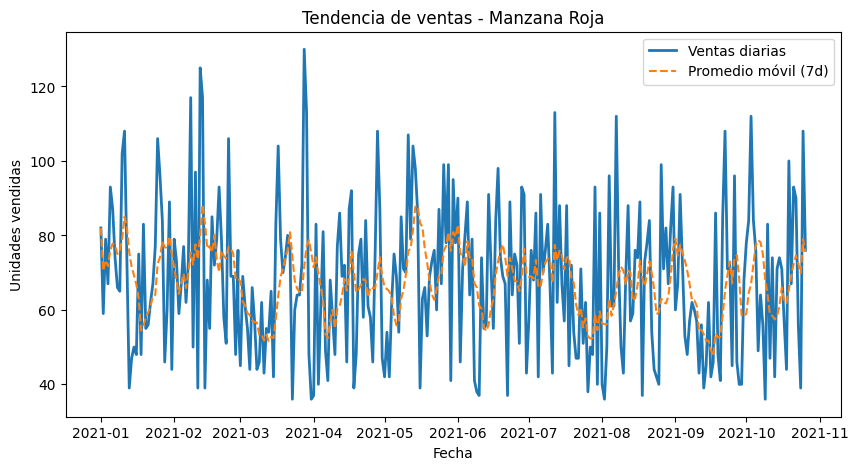

In [12]:
# Selecciona un producto de ejemplo
product_sample = df["product_name"].unique()[0]
df_p = df[df["product_name"] == product_sample]

plt.figure(figsize=(10,5))
plt.plot(df_p["date"], df_p["quantity_sold"], label="Ventas diarias", linewidth=2)
plt.plot(df_p["date"], df_p["sales_mavg_7d"], label="Promedio móvil (7d)", linestyle="--")
plt.title(f"Tendencia de ventas - {product_sample}")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.show()

## **Bloque automatizado: ranking de importancia de features**

Se entrena un modelo lineal usando variables estandarizadas para estimar la importancia relativa de cada feature.
El modelo logra un R² = 0.928, lo que indica un buen nivel de explicación.

Las variables más influyentes según la magnitud de sus coeficientes son:
1. `total_sales_value`
2. `price_per_unit`
3. `stock_available`
4. `week`
5. `day_of_year`

Este análisis permite priorizar qué características aportan más en una relación lineal con el objetivo.

R² del modelo lineal explicativo: 0.928


,feature,coef,abs_importance
1,total_sales_value,27.463283,27.463283
8,price_per_unit,-23.457026,23.457026
4,stock_available,-4.947791,4.947791
0,ratio_sold_stock,-3.752797,3.752797
2,sales_mavg_7d,2.579662,2.579662
3,price_var,0.667479,0.667479
5,replenishment,0.521297,0.521297
6,week,-0.179907,0.179907
7,day_of_year,0.089458,0.089458


/var/folders/y7/qjs9d18x2w740zzd5hmnjy5c0000gn/T/ipykernel_21778/663911170.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x="abs_importance", y="feature", palette="viridis")


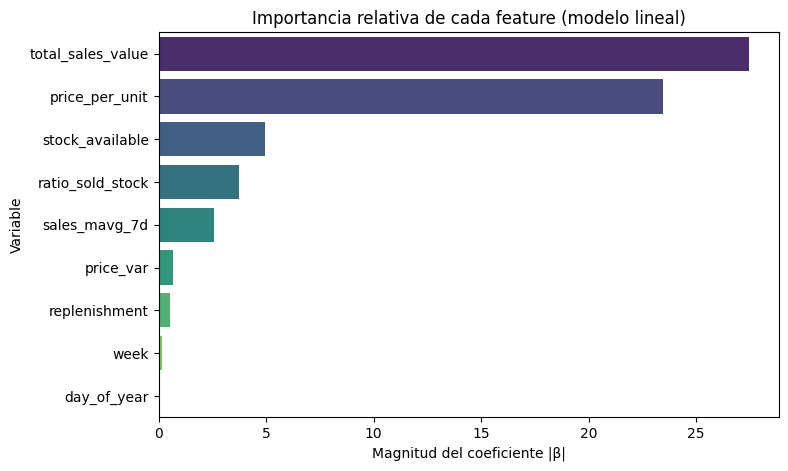

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Seleccionar features numéricas (excepto el target)
features = ["ratio_sold_stock", "total_sales_value", "sales_mavg_7d",
            "price_var", "stock_available", "replenishment",
            "week", "day_of_year", "price_per_unit"]

X = df[features].fillna(0)
y = df["quantity_sold"]

# Escalado estandar para que las magnitudes no distorsionen
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo lineal simple para estimar importancia
model = LinearRegression()
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

importances = pd.DataFrame({
    "feature": features,
    "coef": model.coef_,
    "abs_importance": np.abs(model.coef_)
}).sort_values("abs_importance", ascending=False)

print(f"R² del modelo lineal explicativo: {r2:.3f}")
display(importances)

# Visualización
plt.figure(figsize=(8,5))
sns.barplot(data=importances, x="abs_importance", y="feature", palette="viridis")
plt.title("Importancia relativa de cada feature (modelo lineal)")
plt.xlabel("Magnitud del coeficiente |β|")
plt.ylabel("Variable")
plt.show()

## **Crear dataset final para la Fase B**

Se selecciona un subconjunto de features relevantes para el modelo predictivo final y se exporta como `dataset_final.csv`.
Este archivo contiene únicamente las columnas esenciales para entrenar de forma eficiente el modelo posterior.

In [14]:
selected_features = [
    "product_id", 
    "date",
    
    # target
    "quantity_sold",
    
    # features seguras
    "stock_available",
    "sales_mavg_7d",
    "ratio_sold_stock",
    "price_per_unit",
    "day_of_week",
    "month",
    "is_weekend"
]

df_model = df[selected_features].copy()
df_model.to_csv("../data/processed/dataset_final.csv", index=False)
print("Dataset final guardado en correctamente")

Dataset final guardado en correctamente
